In [ ]:
# Import thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [ ]:
# 1. Tạo dữ liệu KHÔNG tuyến tính
X, y = make_moons(
    n_samples=200,
    noise=0.15,
    random_state=42
)

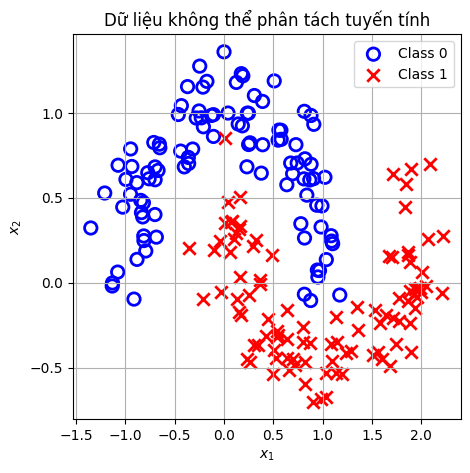

In [ ]:
# 2. Vẽ hình trực quan hoá dữ liệu vừa tạo
plt.figure(figsize=(5,5))
plt.scatter(
    X[y==0, 0], X[y==0, 1],
    facecolors='none', edgecolors='blue',
    s=80, linewidths=2, label='Class 0'
)
plt.scatter(
    X[y==1, 0], X[y==1, 1],
    marker='x', color='red',
    s=80, linewidths=2, label='Class 1'
)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Dữ liệu không thể phân tách tuyến tính")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Tạo lưới để vẽ decision boundary
h = 0.02
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]

In [ ]:
# 4. Định nghĩa một mạng MLP để huấn luyện cho dữ liệu vừa tạo
model = MLPClassifier(
    hidden_layer_sizes=(16, 16), # 2 hidden layers
    activation='tanh', # activation function
    solver='adam',
    learning_rate_init=0.01,
    max_iter=1,
    warm_start=True,
    random_state=42
)

In [ ]:
# Hàm vẽ decision boundary tại mỗi epoch
def plot_decision_boundary(epoch, model):
    Z = model.predict_proba(grid)[:, 1]
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(6,6))
    # Nền xác suất
    plt.contourf(
        xx, yy, Z,
        levels=50,
        cmap=plt.cm.coolwarm,
        alpha=0.8
    )

    # Đường biên p = 0.5
    plt.contour(
        xx, yy, Z,
        levels=[0.5],
        colors='blue',
        linewidths=2
    )

    # Dữ liệu
    plt.scatter(
        X[y==0, 0], X[y==0, 1],
        facecolors='none', edgecolors='blue',
        s=80, linewidths=2
    )
    plt.scatter(
        X[y==1, 0], X[y==1, 1],
        marker='x', color='red',
        s=80, linewidths=2
    )

    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.title(f"Decision Boundary at Epoch {epoch}")
    plt.grid(True)
    plt.show()

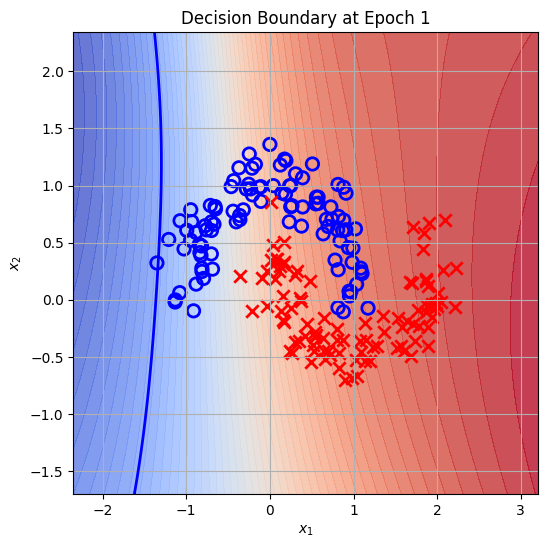

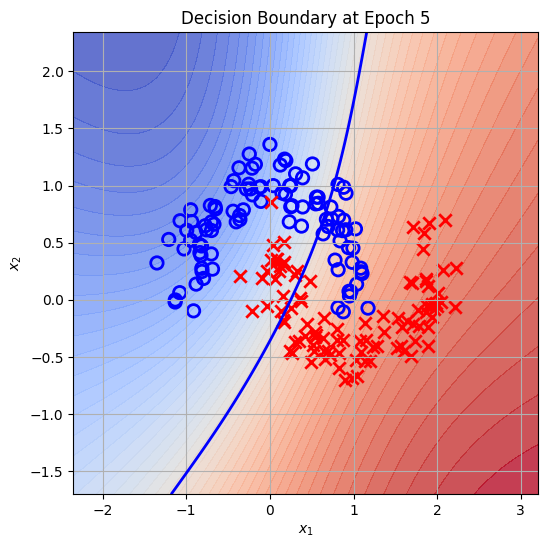

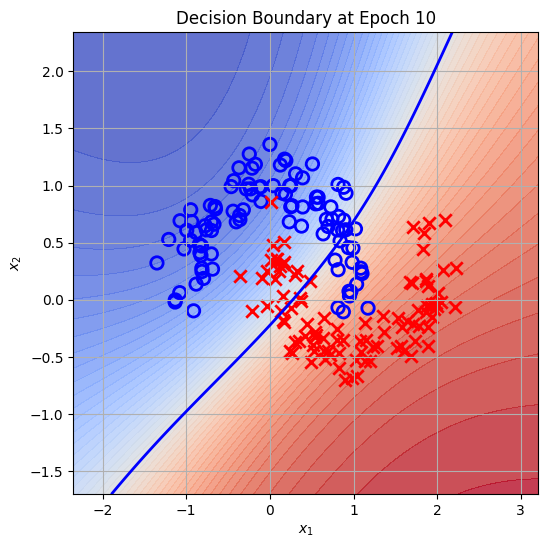

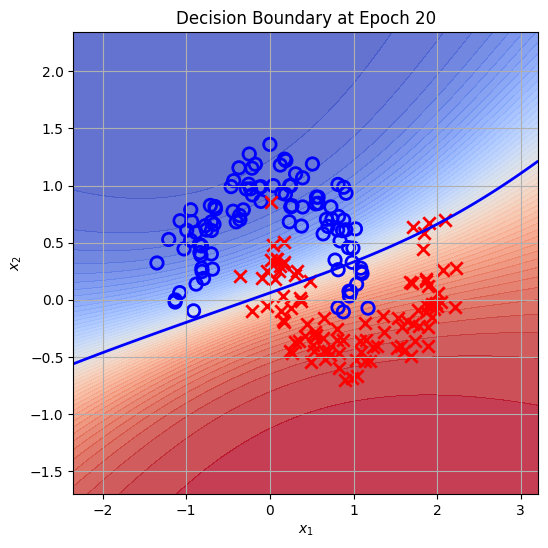

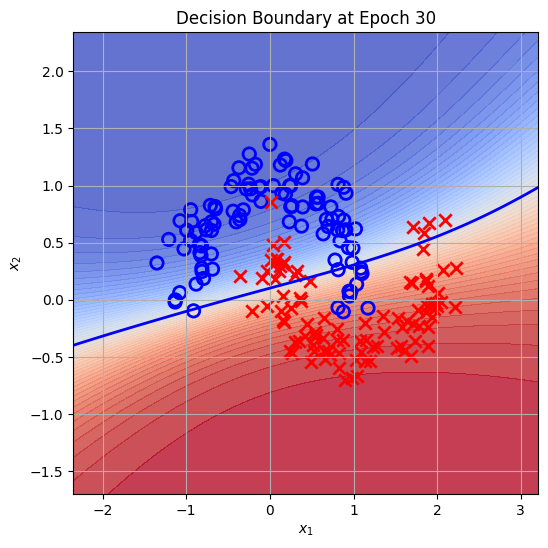

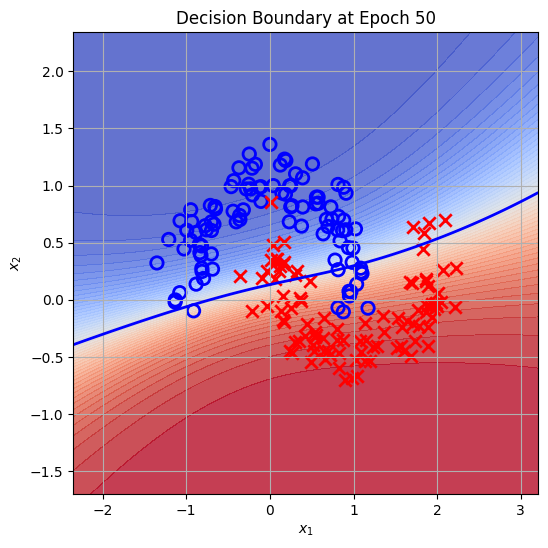

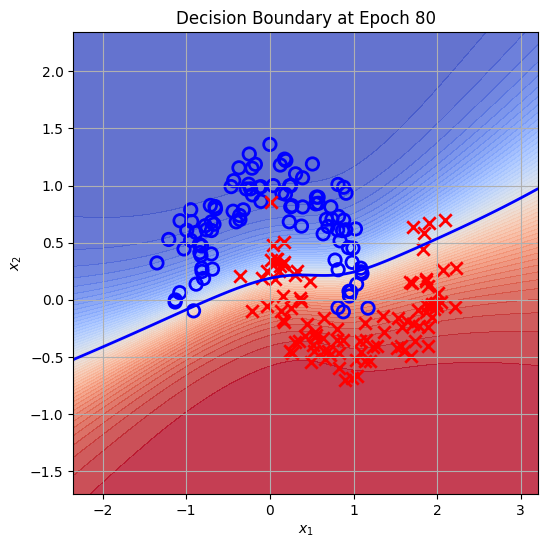

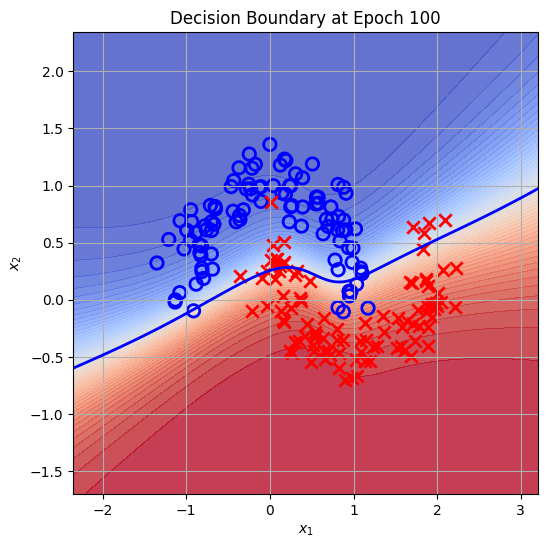

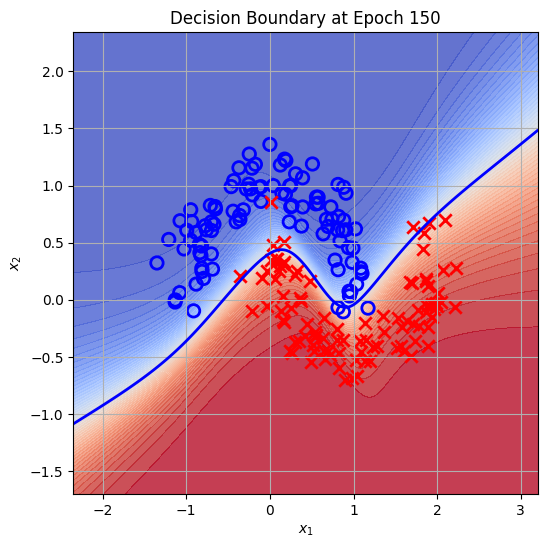

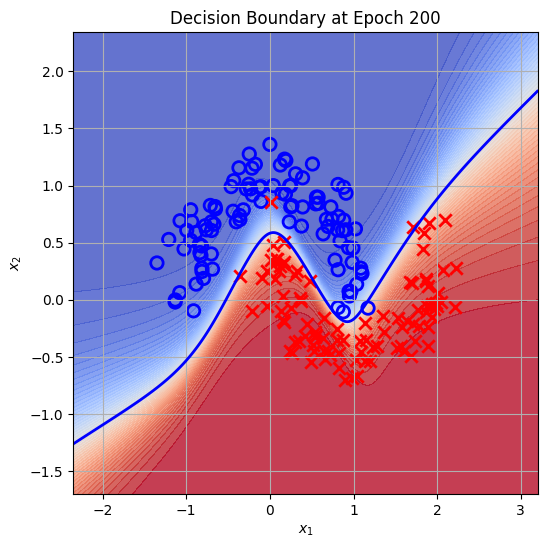

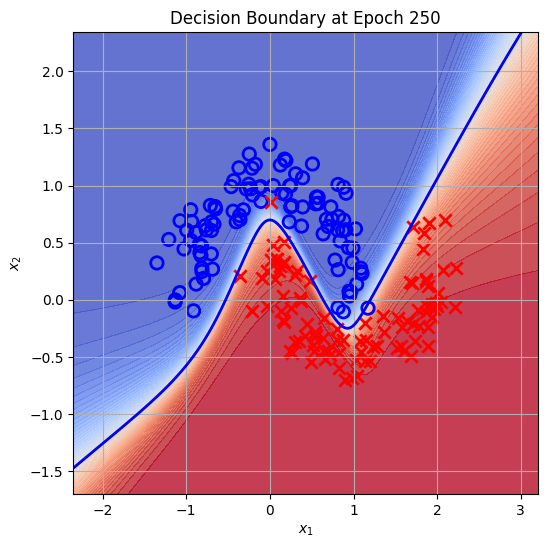

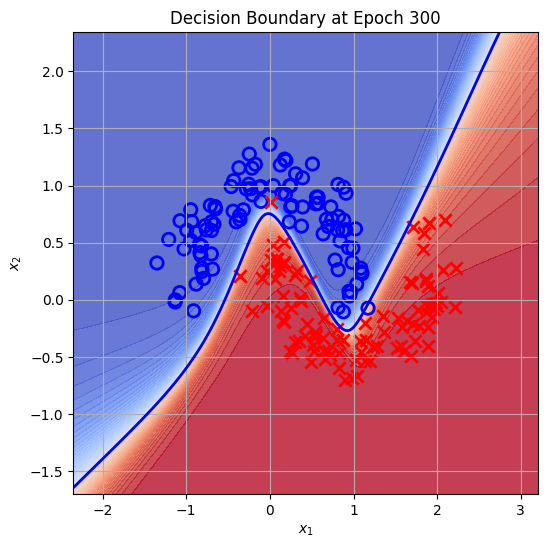

In [ ]:
# Qúa trình training và hội tụ
EPOCHS = 300

for epoch in range(1, EPOCHS + 1):
    model.fit(X, y)

    # Vẽ ở các epoch tiêu biểu để dễ quan sát
    if epoch in [1, 5, 10, 20, 30, 50, 80, 100, 150, 200, 250, 300]:
        plot_decision_boundary(epoch, model)

### BÀI TẬP LÝ THUYẾT & PHÂN TÍCH (Câu 1, 2, 5, 7)

#### **Câu 1: Shape của input X và nhãn y**
* Nhìn vào code khởi tạo dữ liệu: `X, y = make_moons(n_samples=200, noise=0.15, random_state=42)`
* **`X.shape`**: `(200, 2)` (gồm 200 mẫu thử, mỗi mẫu có 2 đặc trưng tọa độ $x_1, x_2$).
* **`y.shape`**: `(200,)` (mảng 1 chiều chứa 200 nhãn phân lớp 0 hoặc 1).

#### **Câu 2: Kiến trúc mạng MLP trong bài**
* **Số neuron ở Input layer**: `2` (tương ứng với 2 đặc trưng đầu vào $x_1$ và $x_2$).
* **Số lượng Hidden layers**: `2` (được định nghĩa qua tham số `hidden_layer_sizes=(16, 16)`).
* **Số neuron ở mỗi hidden layer**: `16` neuron ở hidden layer 1 và `16` neuron ở hidden layer 2.
* **Số neuron ở Output layer**: `1` (bài toán phân loại nhị phân nhãn $0$ hoặc $1$).

#### **Câu 5: Tăng số neuron từ 16 → 64 mạng có luôn tốt hơn không?**
* **Không luôn tốt hơn**. Khi tăng số neuron lên quá lớn (ví dụ 64 ở cả 2 lớp), mô hình sẽ có khả năng biểu diễn (capacity) cực kỳ mạnh.
* Tuy nhiên, điều này đi kèm với 2 nguy cơ lớn:
  1. **Overfitting (Quá khớp)**: Mạng sẽ cố gắng học cả các điểm nhiễu (`noise=0.15`) của dữ liệu train, tạo ra đường biên phân lớp cực kỳ uốn lượn phức tạp, dẫn đến khả năng tổng quát hóa kém trên dữ liệu mới.
  2. **Chi phí tính toán**: Thời gian training sẽ tăng lên do số lượng trọng số cần tối ưu hóa nhiều hơn đáng kể.

#### **Câu 7: Tính số lượng parameters cho mạng ban đầu (Input: 2 -> Hidden 1: 16 -> Hidden 2: 16 -> Output: 1)**
Công thức tính tham số (weights + biases) giữa 2 tầng liên tiếp là: $\text{Params} = (N_{\text{in}} \times N_{\text{out}}) + N_{\text{out}}$

1. **Giữa Input (2) và Hidden 1 (16):**
   * Weights: $2 \times 16 = 32$
   * Biases: $16$
   * **Tổng cộng**: $32 + 16 = 48$
2. **Giữa Hidden 1 (16) và Hidden 2 (16):**
   * Weights: $16 \times 16 = 256$
   * Biases: $16$
   * **Tổng cộng**: $256 + 16 = 272$
3. **Giữa Hidden 2 (16) và Output (1):**
   * Weights: $16 \times 1 = 16$
   * Biases: $1$
   * **Tổng cộng**: $16 + 1 = 17$

**👉 Tổng số lượng parameters của toàn mạng:** $48 + 272 + 17 = 337$ parameters.

In [ ]:
# 1. In ra shape thực tế để kiểm tra câu 1
print(f"Shape của X: {X.shape}")
print(f"Shape của y: {y.shape}")

Shape của X: (200, 2)
Shape của y: (200,)


### BÀI TẬP THỰC NGHIỆM (Câu 3, 4, 6)

Độ chính xác mạng 1 hidden layer (16,): 0.975


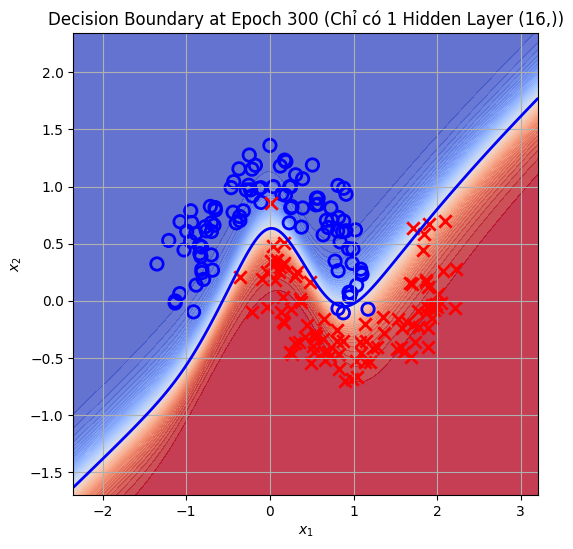

In [ ]:
# Câu 3: Thử bỏ hidden layer 2, chỉ giữ lại hidden layer 1: (16,)
model_single_layer = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation='tanh',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=1,
    warm_start=True,
    random_state=42
)

# Train qua 300 epochs
for epoch in range(1, 301):
    model_single_layer.fit(X, y)

print("Độ chính xác mạng 1 hidden layer (16,):", model_single_layer.score(X, y))
plot_decision_boundary("300 (Chỉ có 1 Hidden Layer (16,))", model_single_layer)

**Nhận xét Câu 3**: Mạng chỉ có 1 hidden layer gồm 16 neuron vẫn giải quyết rất tốt bài toán này nhờ hàm kích hoạt phi tuyến `tanh`. Đường biên phân lớp vẫn mượt mà và bao phủ trọn vẹn hai nửa vầng trăng.

Độ chính xác mạng hidden layers (4, 4): 0.95


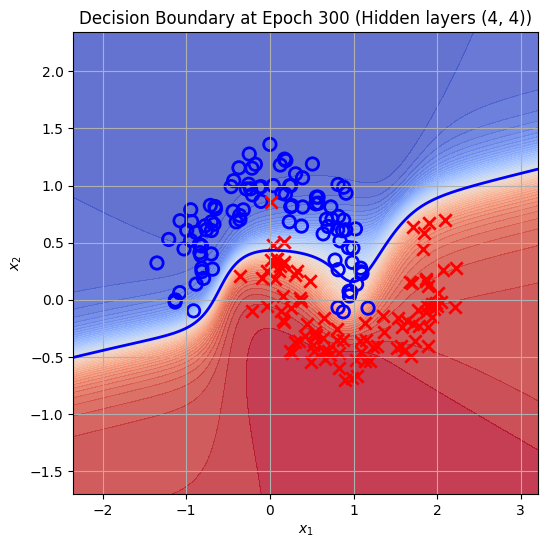

In [ ]:
# Câu 4: Thay đổi số neuron của hidden layers từ (16, 16) -> (4, 4)
model_small = MLPClassifier(
    hidden_layer_sizes=(4, 4),
    activation='tanh',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=1,
    warm_start=True,
    random_state=42
)

# Train qua 300 epochs
for epoch in range(1, 301):
    model_small.fit(X, y)

print("Độ chính xác mạng hidden layers (4, 4):", model_small.score(X, y))
plot_decision_boundary("300 (Hidden layers (4, 4))", model_small)

**Nhận xét Câu 4**: Khi giảm số neuron xuống còn `(4, 4)`, mạng vẫn có khả năng phân tách cơ bản nhưng đường biên phân lớp (Decision Boundary) bắt đầu kém mượt mà hơn (xuất hiện nhiều đường thẳng gãy khúc do số lượng tổ hợp tuyến tính giảm đi).

Độ chính xác với hàm kích hoạt [logistic]: 0.8500


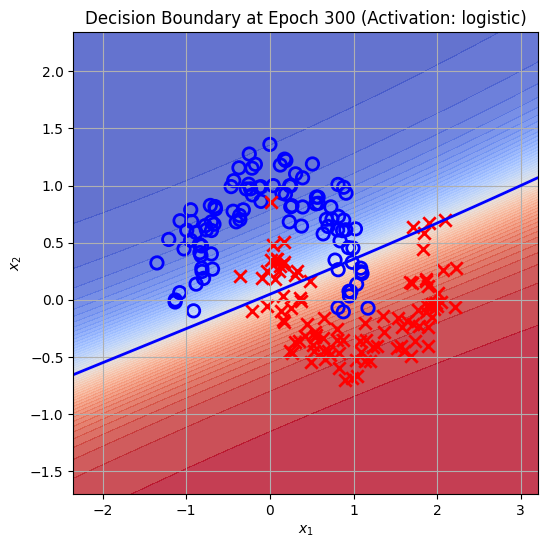

Độ chính xác với hàm kích hoạt [tanh]: 0.9900


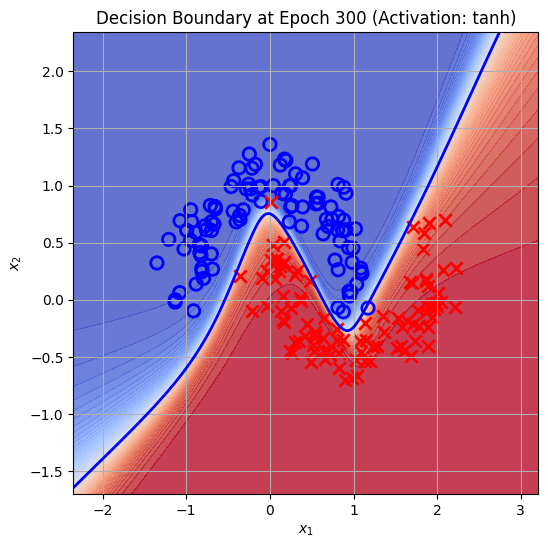

Độ chính xác với hàm kích hoạt [relu]: 0.9850


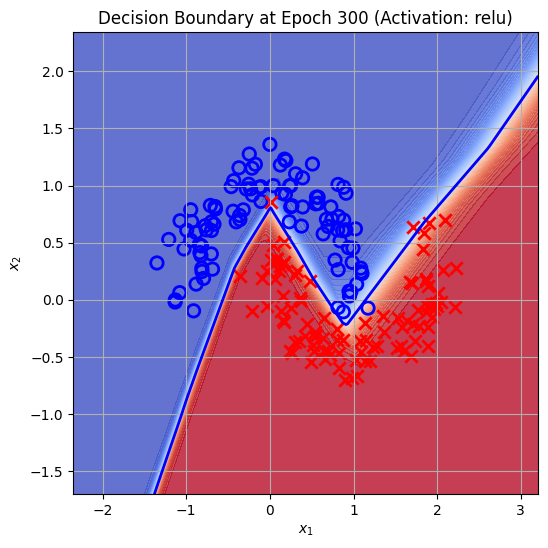

In [ ]:
# Câu 6: So sánh 3 hàm activation function: sigmoid, tanh, relu
activations = ['logistic', 'tanh', 'relu'] # 'logistic' chính là sigmoid trong sklearn

for act in activations:
    model_act = MLPClassifier(
        hidden_layer_sizes=(16, 16),
        activation=act,
        solver='adam',
        learning_rate_init=0.01,
        max_iter=1,
        warm_start=True,
        random_state=42
    )

    # Train qua 300 epochs
    for epoch in range(1, 301):
        model_act.fit(X, y)

    print(f"Độ chính xác với hàm kích hoạt [{act}]: {model_act.score(X, y):.4f}")
    plot_decision_boundary(f"300 (Activation: {act})", model_act)

**Nhận xét Câu 6 - So sánh các hàm kích hoạt (Activation Functions):**
* **`sigmoid` (logistic)**: Có tốc độ hội tụ chậm hơn, đường biên mượt mà nhưng đôi khi có xu hướng bị bão hòa đạo hàm (vanishing gradient) nếu cấu trúc mạng sâu hơn.
* **`tanh`**: Hội tụ nhanh hơn sigmoid nhờ tính chất đối xứng qua gốc tọa độ (zero-centered), đường biên rất mượt và bo tròn đẹp mắt.
* **`relu`**: Hội tụ cực kỳ nhanh, tuy nhiên vì bản chất hàm ReLU là tuyến tính từng phần ($max(0, x)$), đường biên phân lớp trông sẽ vuông vức và sắc cạnh (polygon-like boundary) chứ không uốn lượn cong mượt mà như tanh.